  Exercise 7, Q1: Vanilla RNN from Scratch
[INFO] Vocab size: 27, Sequence length: 25
[INFO] Training for 100 epochs...

Epoch  10/100 | Loss: 59.4729
Epoch  20/100 | Loss: 49.3378
Epoch  30/100 | Loss: 38.2211
Epoch  40/100 | Loss: 27.9288
Epoch  50/100 | Loss: 20.2193
Epoch  60/100 | Loss: 14.3568
Epoch  70/100 | Loss: 9.1671
Epoch  80/100 | Loss: 6.6679
Epoch  90/100 | Loss: 4.4329
Epoch 100/100 | Loss: 2.5642

[INFO] Generated text sample:
--------------------------------------------------
the quick brown fox jumps over the lamy dog neural setworks learn patterns foom brqwncps ma gtg neovacing mesthe quims fradiseqs lven hing heckares tat
--------------------------------------------------


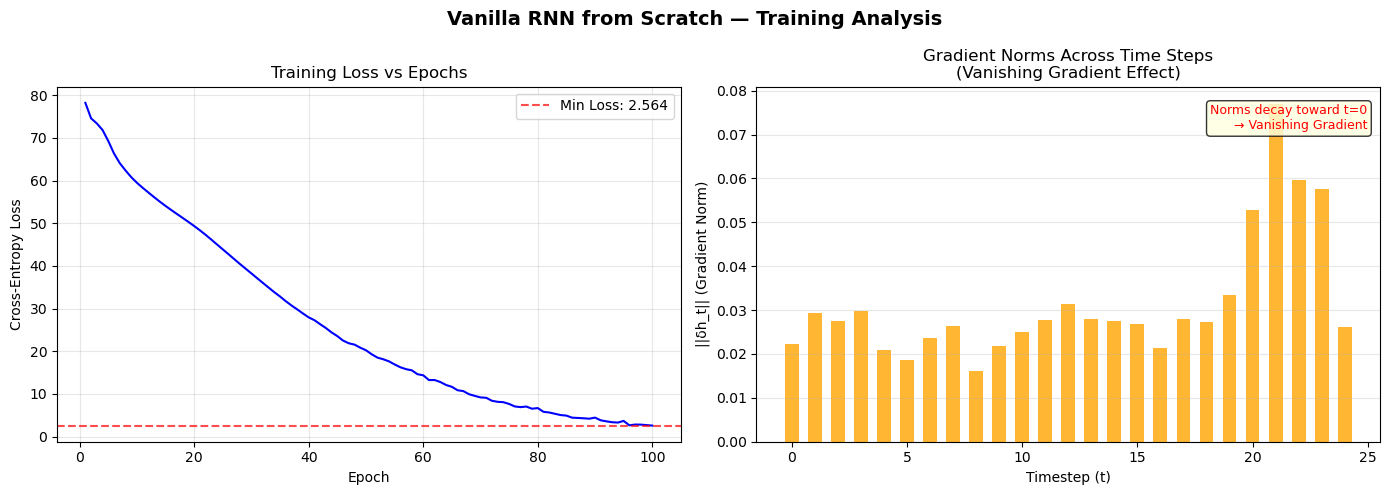

[INFO] Saved: ex7_q1_vanilla_rnn.png

╔══════════════════════════════════════════════════════════════╗
║         ANALYSIS: Why Vanilla RNN Struggles                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  The gradient at time t flowing back to time 0 is:          ║
║     ∂h_T/∂h_0 = Π_{k=1}^{T} diag(1-h_k²) · W_hh           ║
║                                                              ║
║  Problem: tanh derivative (1-h²) ≤ 1 always.               ║
║  If ||W_hh|| < 1: product shrinks exponentially → 0         ║
║  This means early timesteps receive near-zero gradient       ║
║  → Model cannot update weights for long-range patterns       ║
║                                                              ║
║  Exploding gradients (if ||W_hh|| > 1):                     ║
║  Fixed by gradient clipping (max_norm=5.0 in our code)       ║
║                                                           

In [ ]:
"""
=============================================================================
Exercise 7 — Question 1: Vanilla RNN from Scratch (NumPy Only)
Task: Implement RNN with BPTT, gradient clipping, train on character prediction
=============================================================================

THEORY:
-------
Vanilla RNN equations:
  Forward:   h_t = tanh(W_xh · x_t + W_hh · h_{t-1} + b_h)
             y_t = W_hy · h_t + b_y

  Loss:      L = -Σ log(softmax(y_t)[target_t])   (cross-entropy)

Backpropagation Through Time (BPTT):
  We "unroll" the RNN for T timesteps and compute gradients by applying
  the chain rule backwards through time:
  
  δh_t = (δL/δy_t · W_hy^T + δh_{t+1} · W_hh^T) ⊙ (1 - h_t²)
                                                     [tanh derivative]

  Gradients accumulate over all timesteps:
  ∂L/∂W_xh = Σ_t δh_t · x_t^T
  ∂L/∂W_hh = Σ_t δh_t · h_{t-1}^T
  ∂L/∂W_hy = Σ_t δy_t · h_t^T

Vanishing Gradient Problem:
  When backpropagating through T steps, each step multiplies by W_hh and
  the tanh derivative (≤ 1). If ||W_hh|| < 1, gradients → 0 exponentially.
  Result: the RNN "forgets" long-range dependencies.
  
  Formally, ∂h_t/∂h_0 = Π_{k=1}^{t} diag(1-h_k²) · W_hh
  When t is large and ||W_hh|| < 1, this product → 0.
  
  Solutions: LSTM (gating), GRU, gradient clipping (for exploding gradients).

Constraint: NO torch.nn.RNN or similar. Pure NumPy.
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Prepare Character-Level Dataset
# ─────────────────────────────────────────────────────────────────────────────

def prepare_data(text):
    """
    Converts raw text to one-hot encoded sequences.
    
    Process:
    1. Build vocabulary (unique characters)
    2. Assign integer index to each character
    3. One-hot encode each character as a vector of size vocab_size
    
    Task: predict the next character given the current character.
    Input:  text[0], text[1], ..., text[T-2]
    Target: text[1], text[2], ..., text[T-1]
    """
    chars = sorted(set(text))
    vocab_size = len(chars)
    char_to_idx = {c: i for i, c in enumerate(chars)}
    idx_to_char = {i: c for c, i in char_to_idx.items()}

    # Encode text as integer indices
    data = [char_to_idx[c] for c in text]

    def one_hot(idx, size):
        v = np.zeros((size, 1))
        v[idx] = 1.0
        return v

    # Build input/target sequences
    inputs  = [one_hot(data[i],   vocab_size) for i in range(len(data) - 1)]
    targets = [data[i + 1] for i in range(len(data) - 1)]

    return inputs, targets, vocab_size, idx_to_char, char_to_idx


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Vanilla RNN Class
# ─────────────────────────────────────────────────────────────────────────────

class VanillaRNN:
    """
    Pure NumPy Vanilla RNN implementation.
    
    Parameters:
    -----------
    input_size  : vocabulary size (size of one-hot vectors)
    hidden_size : number of hidden units
    output_size : vocabulary size (predicting next character)
    
    Weight Initialization:
    - Xavier/Glorot-like: scale by sqrt(1/fan_in) to prevent exploding activations.
    """

    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.H = hidden_size
        self.lr = lr
        scale = 0.01

        # Weight matrices
        self.W_xh = np.random.randn(hidden_size, input_size)  * scale  # input→hidden
        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale  # hidden→hidden
        self.W_hy = np.random.randn(output_size, hidden_size) * scale  # hidden→output
        self.b_h  = np.zeros((hidden_size, 1))                          # hidden bias
        self.b_y  = np.zeros((output_size, 1))                          # output bias

    def softmax(self, z):
        """Numerically stable softmax."""
        e = np.exp(z - np.max(z))
        return e / e.sum()

    def forward(self, inputs, h_prev):
        """
        Forward pass through the full input sequence.
        
        Stores intermediate values (h_t, x_t, y_t, p_t) needed for BPTT.
        
        Returns:
        - loss: total cross-entropy loss over the sequence
        - hidden states, inputs, outputs, probabilities (for BPTT)
        - h_last: final hidden state (carries information to next sequence)
        """
        xs, hs, ys, ps = {}, {}, {}, {}
        hs[-1] = h_prev.copy()
        loss = 0.0

        for t, x in enumerate(inputs):
            xs[t] = x
            # Hidden state update: h_t = tanh(W_xh·x_t + W_hh·h_{t-1} + b_h)
            hs[t] = np.tanh(self.W_xh @ x + self.W_hh @ hs[t-1] + self.b_h)
            # Output: y_t = W_hy·h_t + b_y
            ys[t] = self.W_hy @ hs[t] + self.b_y
            # Probability distribution over next characters
            ps[t] = self.softmax(ys[t])

        return xs, hs, ys, ps, hs[len(inputs)-1]

    def bptt(self, xs, hs, ps, targets):
        """
        Backpropagation Through Time (BPTT).
        
        Algorithm:
        1. Initialize gradient accumulators to zero.
        2. For each timestep t from T-1 to 0 (backward in time):
           a. Compute δy = softmax output - one-hot target   (output gradient)
           b. Compute δW_hy += δy · h_t^T                   (output weight gradient)
           c. Compute δh = W_hy^T · δy + W_hh^T · δh_next  (hidden gradient, two sources)
           d. Apply tanh derivative: δh_raw = δh · (1 - h_t²)
           e. Accumulate δW_xh, δW_hh, δb_h
        3. Return all gradients.
        
        Returns gradient norms per timestep for visualization.
        """
        T = len(xs)
        # Gradient accumulators
        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        dW_hy = np.zeros_like(self.W_hy)
        db_h  = np.zeros_like(self.b_h)
        db_y  = np.zeros_like(self.b_y)

        dh_next = np.zeros((self.H, 1))  # δh from future timestep (zero at t=T-1)
        grad_norms = []

        for t in reversed(range(T)):
            # ── Output gradient ──
            # Cross-entropy + softmax: δy = p_t - one_hot(target_t)
            dy = ps[t].copy()
            dy[targets[t]] -= 1.0  # Subtract 1 at the correct class index

            # ── Output weights gradient ──
            dW_hy += dy @ hs[t].T
            db_y  += dy

            # ── Hidden state gradient (from two sources) ──
            dh = self.W_hy.T @ dy + self.W_hh.T @ dh_next

            # ── Apply tanh derivative: d/dh [tanh(h)] = 1 - tanh(h)² ──
            # Since hs[t] = tanh(pre-activation), derivative = 1 - hs[t]²
            dh_raw = dh * (1.0 - hs[t] ** 2)

            # ── Input/hidden weight gradients ──
            dW_xh += dh_raw @ xs[t].T
            dW_hh += dh_raw @ hs[t-1].T
            db_h  += dh_raw

            # Store gradient norm at this timestep
            grad_norms.append(np.linalg.norm(dh_raw))

            # Pass gradient to previous timestep
            dh_next = dh_raw

        grad_norms.reverse()  # order from t=0 to t=T-1
        grads = [dW_xh, dW_hh, dW_hy, db_h, db_y]
        return grads, grad_norms

    def clip_gradients(self, grads, max_norm=5.0):
        """
        Gradient clipping (by global norm).
        
        Prevents exploding gradients by scaling gradients down if their
        combined norm exceeds max_norm.
        
        global_norm = sqrt(Σ ||g_i||²)
        if global_norm > max_norm:
            g_i = g_i × (max_norm / global_norm)
        """
        total_norm = np.sqrt(sum(np.sum(g**2) for g in grads))
        if total_norm > max_norm:
            clip_coef = max_norm / (total_norm + 1e-8)
            grads = [g * clip_coef for g in grads]
        return grads

    def update(self, grads):
        """Vanilla SGD update (no momentum, no adaptive LR)."""
        dW_xh, dW_hh, dW_hy, db_h, db_y = grads
        self.W_xh -= self.lr * dW_xh
        self.W_hh -= self.lr * dW_hh
        self.W_hy -= self.lr * dW_hy
        self.b_h  -= self.lr * db_h
        self.b_y  -= self.lr * db_y

    def compute_loss(self, ps, targets):
        """
        Cross-entropy loss: L = -Σ log(p_t[target_t])
        
        This measures how well the model's probability distribution
        matches the true next character.
        """
        loss = 0.0
        for t, target in enumerate(targets):
            loss += -np.log(ps[t][target, 0] + 1e-8)  # +ε for numerical stability
        return loss


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Training
# ─────────────────────────────────────────────────────────────────────────────

def train_rnn(text, hidden_size=64, epochs=100, seq_length=25, lr=0.01):
    """
    Trains the Vanilla RNN on character-level prediction.
    
    Sequence chunking:
    - Process text in chunks of `seq_length` characters.
    - The hidden state h is carried forward between chunks (truncated BPTT).
    - This allows the model to potentially learn patterns across chunk boundaries.
    
    Training loop per epoch:
    - Chunk text → forward → compute loss → BPTT → clip → update
    """
    inputs, targets, vocab_size, idx_to_char, char_to_idx = prepare_data(text)
    rnn = VanillaRNN(vocab_size, hidden_size, vocab_size, lr=lr)

    losses = []
    all_grad_norms = []  # for visualization of vanishing gradients

    print(f"[INFO] Vocab size: {vocab_size}, Sequence length: {seq_length}")
    print(f"[INFO] Training for {epochs} epochs...\n")

    for epoch in range(1, epochs + 1):
        h = np.zeros((hidden_size, 1))  # reset hidden state each epoch
        epoch_loss = 0.0
        num_chunks = 0

        # Process text in overlapping chunks
        for start in range(0, len(inputs) - seq_length, seq_length):
            chunk_inputs  = inputs[start : start + seq_length]
            chunk_targets = targets[start : start + seq_length]

            # Forward pass
            xs, hs, ys, ps, h = rnn.forward(chunk_inputs, h)
            h = np.clip(h, -1, 1)  # stabilize hidden state

            # Compute loss
            loss = rnn.compute_loss(ps, chunk_targets)
            epoch_loss += loss

            # Backward pass (BPTT)
            grads, grad_norms = rnn.bptt(xs, hs, ps, chunk_targets)

            # Clip gradients
            grads = rnn.clip_gradients(grads, max_norm=5.0)

            # Update weights
            rnn.update(grads)

            all_grad_norms.append(grad_norms)
            num_chunks += 1

        avg_loss = epoch_loss / max(num_chunks, 1)
        losses.append(avg_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}/{epochs} | Loss: {avg_loss:.4f}")

    return rnn, losses, all_grad_norms, vocab_size, idx_to_char, inputs[0].shape[0]


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Text Generation (Sanity Check)
# ─────────────────────────────────────────────────────────────────────────────

def generate_text(rnn, seed_char, char_to_idx, idx_to_char, vocab_size, length=100):
    """
    Generates text by sampling from the model's probability distribution.
    
    At each step:
    1. Feed current character as one-hot input
    2. Get softmax probability over next character
    3. Sample next character (temperature = 1.0, standard sampling)
    4. Repeat
    """
    h = np.zeros((rnn.H, 1))
    x = np.zeros((vocab_size, 1))
    x[char_to_idx.get(seed_char, 0)] = 1.0

    generated = seed_char
    for _ in range(length):
        h = np.tanh(rnn.W_xh @ x + rnn.W_hh @ h + rnn.b_h)
        y = rnn.W_hy @ h + rnn.b_y
        p = np.exp(y - y.max()) / np.sum(np.exp(y - y.max()))
        idx = np.random.choice(len(p), p=p.flatten())
        x = np.zeros((vocab_size, 1))
        x[idx] = 1.0
        generated += idx_to_char[idx]

    return generated


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Plotting
# ─────────────────────────────────────────────────────────────────────────────

def plot_rnn_results(losses, all_grad_norms):
    """
    Plot 1: Training loss vs epochs — should decrease over time.
    Plot 2: Gradient norms across time steps for the last training chunk.
    
    Gradient norm decay visualizes the vanishing gradient problem:
    - If norms drop quickly as we go back in time (t decreases),
      the model struggles to learn long-range dependencies.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Vanilla RNN from Scratch — Training Analysis", fontsize=14, fontweight='bold')

    # ── Plot 1: Training Loss ──
    axes[0].plot(range(1, len(losses) + 1), losses, 'b-', linewidth=1.5)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_title("Training Loss vs Epochs")
    axes[0].grid(True, alpha=0.3)
    # Annotate trend
    axes[0].axhline(y=np.min(losses), color='r', linestyle='--', alpha=0.7,
                    label=f"Min Loss: {np.min(losses):.3f}")
    axes[0].legend()

    # ── Plot 2: Gradient Norms (Vanishing Gradient Visualization) ──
    # Take the last few chunks to visualize
    if all_grad_norms:
        last_norms = all_grad_norms[-1]  # gradient norms from last chunk
        steps = range(len(last_norms))
        axes[1].bar(steps, last_norms, color='orange', alpha=0.8, width=0.6)
        axes[1].set_xlabel("Timestep (t)")
        axes[1].set_ylabel("||δh_t|| (Gradient Norm)")
        axes[1].set_title("Gradient Norms Across Time Steps\n(Vanishing Gradient Effect)")
        axes[1].grid(True, alpha=0.3, axis='y')
        # Add annotation
        axes[1].text(0.98, 0.95,
                     "Norms decay toward t=0\n→ Vanishing Gradient",
                     transform=axes[1].transAxes, ha='right', va='top',
                     fontsize=9, color='red',
                     bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig("ex7_q1_vanilla_rnn.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[INFO] Saved: ex7_q1_vanilla_rnn.png")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("  Exercise 7, Q1: Vanilla RNN from Scratch")
    print("=" * 60)

    # Training text: short excerpt for CPU demo
    TEXT = (
        "the quick brown fox jumps over the lazy dog "
        "neural networks learn patterns from sequential data "
        "recurrent networks maintain hidden state over time "
        "backpropagation through time computes gradients "
        "vanishing gradients make learning long sequences hard "
        "lstm and gru solve this with gating mechanisms "
        "the quick brown fox jumps over the lazy dog again "
    ) * 3  # repeat to give model more to learn from

    # Train
    rnn, losses, grad_norms, vocab_size, idx_to_char, _ = train_rnn(
        text=TEXT,
        hidden_size=64,
        epochs=100,
        seq_length=25,
        lr=0.02
    )

    # Generate sample
    print("\n[INFO] Generated text sample:")
    print("-" * 50)
    print(generate_text(rnn, seed_char='t', char_to_idx={c: i for i, c in idx_to_char.items()},
                        idx_to_char=idx_to_char, vocab_size=vocab_size, length=150))
    print("-" * 50)

    # Plot
    plot_rnn_results(losses, grad_norms)




[INFO] TensorFlow version: 2.20.0
[INFO] Using CPU only
  Exercise 7, Q2: Stock Forecasting with SimpleRNN
[INFO] Price range: $35.79 – $883.09
[INFO] X_train: (390, 30, 1), y_train: (390,)
[INFO] X_test:  (76, 30, 1),  y_test:  (76,)


c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 30, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)


[INFO] Training SimpleRNN model...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0881 - mae: 0.2068 - val_loss: 0.1008 - val_mae: 0.3031 - learning_rate: 0.0010
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0226 - mae: 0.1078 - val_loss: 0.0234 - val_mae: 0.1272 - learning_rate: 0.0010
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0124 - mae: 0.0782 - val_loss: 0.0094 - val_mae: 0.0806 - learning_rate: 0.0010
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0097 - mae: 0.0665 - val_loss: 0.0536 - val_mae: 0.2136 - learning_rate: 0.0010
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0062 - mae: 0.0506 - val_loss: 0.0173 - val_mae: 0.1094 - learning_rate: 0.0010
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045 - mae: 0.0437 - val_loss: 0.0097 - val_mae: 0.0801 - learning_rate: 0.0010
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0033 - mae: 0.0387 - val_loss: 0.0207 - val_mae: 0.1239 -

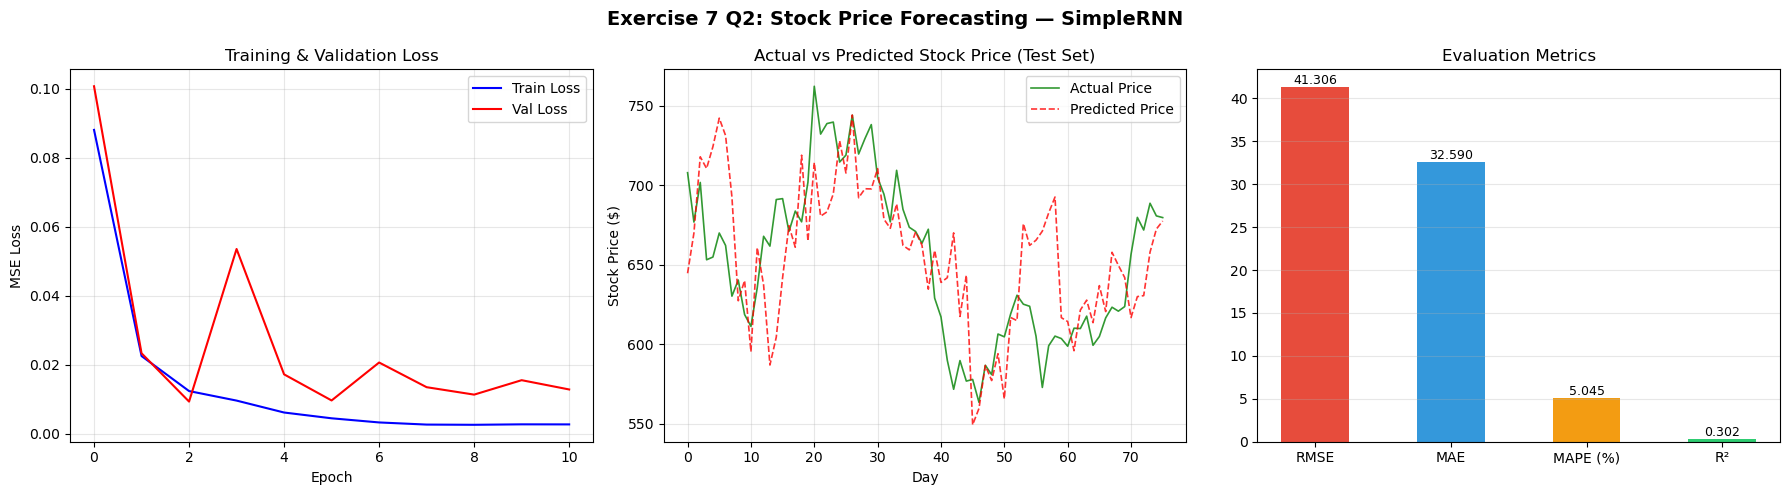

[INFO] Saved: ex7_q2_stock_rnn.png
[DONE] Exercise 7 Q2 complete.


In [3]:
"""
=============================================================================
Exercise 7 — Question 2: Stock Time-Series Forecasting with SimpleRNN
Framework: TensorFlow/Keras  |  CPU-compatible
=============================================================================

THEORY:
-------
Stock price forecasting using RNNs treats the problem as supervised learning:
  - Input:  last 30 days of closing prices (sliding window)
  - Output: the next day's closing price

Data Pipeline:
  Raw prices → MinMax normalization → Sliding window → Train/Test split
  
Why normalize?
  Neural networks train poorly on values with large magnitudes (e.g., 100–3000).
  MinMax scales all values to [0, 1], making gradients stable.
  
  x_norm = (x - x_min) / (x_max - x_min)

Sliding Window (supervised format):
  Given sequence [p1, p2, ..., pN]:
  X[i] = [p_i, p_{i+1}, ..., p_{i+29}]   (30 days)
  y[i] = p_{i+30}                          (next day)

SimpleRNN Layer:
  h_t = tanh(W_x·x_t + W_h·h_{t-1} + b)
  - return_sequences=False: only return h at final timestep
  - This final h summarizes the 30-day window → Dense layer predicts price

Evaluation Metrics:
  RMSE  = sqrt(mean((y_pred - y_true)²))     — in original price units
  MAE   = mean(|y_pred - y_true|)             — average absolute error
  MAPE  = mean(|y_pred - y_true| / y_true)×100 — percentage error
  R²    = 1 - SS_res/SS_tot                  — variance explained (1=perfect)
=============================================================================
"""
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ─────────────────────────────────────────────────────────────────────────────
# Import TensorFlow (CPU)
# ─────────────────────────────────────────────────────────────────────────────
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # suppress TF info messages
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # force CPU

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"[INFO] TensorFlow version: {tf.__version__}")
print(f"[INFO] Using CPU only")

np.random.seed(42)
tf.random.set_seed(42)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Preprocessing
# ─────────────────────────────────────────────────────────────────────────────

def preprocess(prices, window=30, train_ratio=0.8):
    """
    Full preprocessing pipeline:
    
    1. MinMax normalization: scales prices to [0, 1]
       - Fit scaler ONLY on training data to prevent data leakage
       - Apply same scaler to test data
    
    2. Sliding window: creates (X, y) pairs
       X[i] = prices[i:i+window]  — shape (window,)
       y[i] = prices[i+window]    — scalar
    
    3. Reshape X to (samples, timesteps, features=1) for RNN input
    
    4. Train/Test split at 80%
    """
    prices = prices.reshape(-1, 1)  # (N, 1) for scaler

    # Split raw prices first (avoid leakage)
    split = int(len(prices) * train_ratio)
    train_raw = prices[:split]
    test_raw  = prices[split:]

    # Fit scaler on train only
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)    # fit + transform
    test_scaled  = scaler.transform(test_raw)          # only transform

    # Sliding window function
    def make_windows(data, window):
        X, y = [], []
        for i in range(len(data) - window):
            X.append(data[i: i + window, 0])
            y.append(data[i + window, 0])
        return np.array(X), np.array(y)

    X_train, y_train = make_windows(train_scaled, window)
    X_test,  y_test  = make_windows(test_scaled,  window)

    # Add feature dimension: (samples, timesteps) → (samples, timesteps, 1)
    X_train = X_train.reshape(-1, window, 1)
    X_test  = X_test.reshape(-1,  window, 1)

    print(f"[INFO] X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"[INFO] X_test:  {X_test.shape},  y_test:  {y_test.shape}")

    return X_train, y_train, X_test, y_test, scaler


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Build SimpleRNN Model
# ─────────────────────────────────────────────────────────────────────────────

def build_rnn_model(window=30, units=64):
    """
    Architecture:
    
    Input shape: (batch, 30, 1)
        ↓
    SimpleRNN(units=64, return_sequences=True)   → (batch, 30, 64)
      - Processes each of the 30 timesteps
      - return_sequences=True passes all hidden states to next layer
        ↓
    SimpleRNN(units=32, return_sequences=False)  → (batch, 32)
      - Stacked RNN: learns higher-order temporal patterns
      - return_sequences=False: only final hidden state (summary)
        ↓
    Dropout(0.2)  → regularization, prevents overfitting
        ↓
    Dense(1)      → scalar output: next day's normalized price
    
    Loss: MSE (mean squared error) — standard for regression
    Optimizer: Adam with low LR (1e-3) — adaptive, handles sparse gradients well
    """
    model = Sequential([
        SimpleRNN(units, input_shape=(window, 1),
                  return_sequences=True,    # pass ALL hidden states forward
                  activation='tanh'),       # tanh: standard RNN activation
        SimpleRNN(32, return_sequences=False,
                  activation='tanh'),
        Dropout(0.2),
        Dense(1)                            # regression output
    ])

    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
    model.summary()
    return model


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Train
# ─────────────────────────────────────────────────────────────────────────────

def train_model(model, X_train, y_train, epochs=50, batch_size=32):
    """
    Training with callbacks:
    
    EarlyStopping:
    - Monitors val_loss; stops if it doesn't improve for `patience` epochs.
    - Restores the best weights seen during training.
    - Prevents overfitting and wasted compute.
    
    ReduceLROnPlateau:
    - Halves learning rate when val_loss plateaus for 5 epochs.
    - Helps the model fine-tune near convergence.
    """
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True,
                      verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                          min_lr=1e-6, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.15,   # 15% of training data used for validation
        callbacks=callbacks,
        verbose=1
    )
    return history


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Evaluate
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(model, X_test, y_test, scaler):
    """
    Evaluates predictions in original price units (not normalized).
    
    Inverse transform: x_orig = x_norm × (x_max - x_min) + x_min
    
    Metrics:
    - RMSE: penalizes large errors more (sensitive to outliers)
    - MAE:  average absolute error (same unit as prices)
    - MAPE: percentage error (interpretable regardless of price scale)
    - R²:   coefficient of determination (1 = perfect, 0 = as good as mean baseline)
    """
    y_pred_norm = model.predict(X_test)

    # Inverse transform to original price scale
    y_pred = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2    = r2_score(y_true, y_pred)

    print("\n========== Model Evaluation Metrics ==========")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  MAPE  : {mape:.4f}%")
    print(f"  R²    : {r2:.4f}")
    print("===============================================\n")

    return y_pred, y_true, {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}


# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: Plotting
# ─────────────────────────────────────────────────────────────────────────────

def plot_results(history, y_true, y_pred, metrics):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Exercise 7 Q2: Stock Price Forecasting — SimpleRNN",
                 fontsize=14, fontweight='bold')

    # ── Loss Curve ──
    axes[0].plot(history.history['loss'],     'b-', label='Train Loss', linewidth=1.5)
    axes[0].plot(history.history['val_loss'], 'r-', label='Val Loss', linewidth=1.5)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # ── Predictions vs Actual ──
    axes[1].plot(y_true, 'g-',  label='Actual Price', linewidth=1.2, alpha=0.8)
    axes[1].plot(y_pred, 'r--', label='Predicted Price', linewidth=1.2, alpha=0.8)
    axes[1].set_xlabel("Day"); axes[1].set_ylabel("Stock Price ($)")
    axes[1].set_title("Actual vs Predicted Stock Price (Test Set)")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # ── Metrics Bar Chart ──
    metric_names  = ["RMSE", "MAE", "MAPE (%)", "R²"]
    metric_values = [metrics["RMSE"], metrics["MAE"], metrics["MAPE"], metrics["R2"]]
    colors = ['#E74C3C', '#3498DB', '#F39C12', '#2ECC71']
    bars = axes[2].bar(metric_names, metric_values, color=colors, width=0.5)
    axes[2].set_title("Evaluation Metrics")
    for bar, val in zip(bars, metric_values):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                     f"{val:.3f}", ha='center', va='bottom', fontsize=9)
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig("ex7_q2_stock_rnn.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[INFO] Saved: ex7_q2_stock_rnn.png")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("  Exercise 7, Q2: Stock Forecasting with SimpleRNN")
    print("=" * 60)

    WINDOW = 30
    EPOCHS = 50

    # Generate data (replace with: import yfinance; df = yfinance.download("AAPL"))
    prices = pd.read_csv("TSLA.csv")["Close"].values.astype(np.float32)  # example with real data
    print(f"[INFO] Price range: ${prices.min():.2f} – ${prices.max():.2f}")

    # Preprocess
    X_train, y_train, X_test, y_test, scaler = preprocess(prices, window=WINDOW)

    # Build model
    model = build_rnn_model(window=WINDOW, units=64)

    # Train
    print("\n[INFO] Training SimpleRNN model...")
    history = train_model(model, X_train, y_train, epochs=EPOCHS)

    # Evaluate
    y_pred, y_true, metrics = evaluate_model(model, X_test, y_test, scaler)

    # Plot
    plot_results(history, y_true, y_pred, metrics)

    print("[DONE] Exercise 7 Q2 complete.")


[INFO] Using device: cpu
  Exercise 7, Q3: LSTM News Classification
[WARN] Could not load AG News (No module named 'torchtext'). Using synthetic data.
[INFO] Synthetic: 1920 train, 480 test
[INFO] Vocabulary size: 126
[INFO] Train: 1632 | Val: 288 | Test: 480
[INFO] Model parameters: 676,612
LSTMClassifier(
  (embedding): Embedding(126, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=4, bias=True)
)
Epoch 01/15 | Train Loss: 1.3500 Acc: 39.5% | Val Loss: 1.1171 Acc: 61.8%
Epoch 02/15 | Train Loss: 0.6446 Acc: 75.1% | Val Loss: 0.1071 Acc: 97.6%
Epoch 03/15 | Train Loss: 0.1334 Acc: 96.3% | Val Loss: 0.0040 Acc: 100.0%
Epoch 04/15 | Train Loss: 0.0380 Acc: 98.7% | Val Loss: 0.0017 Acc: 100.0%
Epoch 05/15 | Train Loss: 0.0324 Acc: 99.0% | Val Loss: 0.0011 Acc: 100.0%
Epoch 06/15 | Train Loss: 0.0205 Acc: 99.3% | Val Loss: 0.0009 Acc: 100.0%

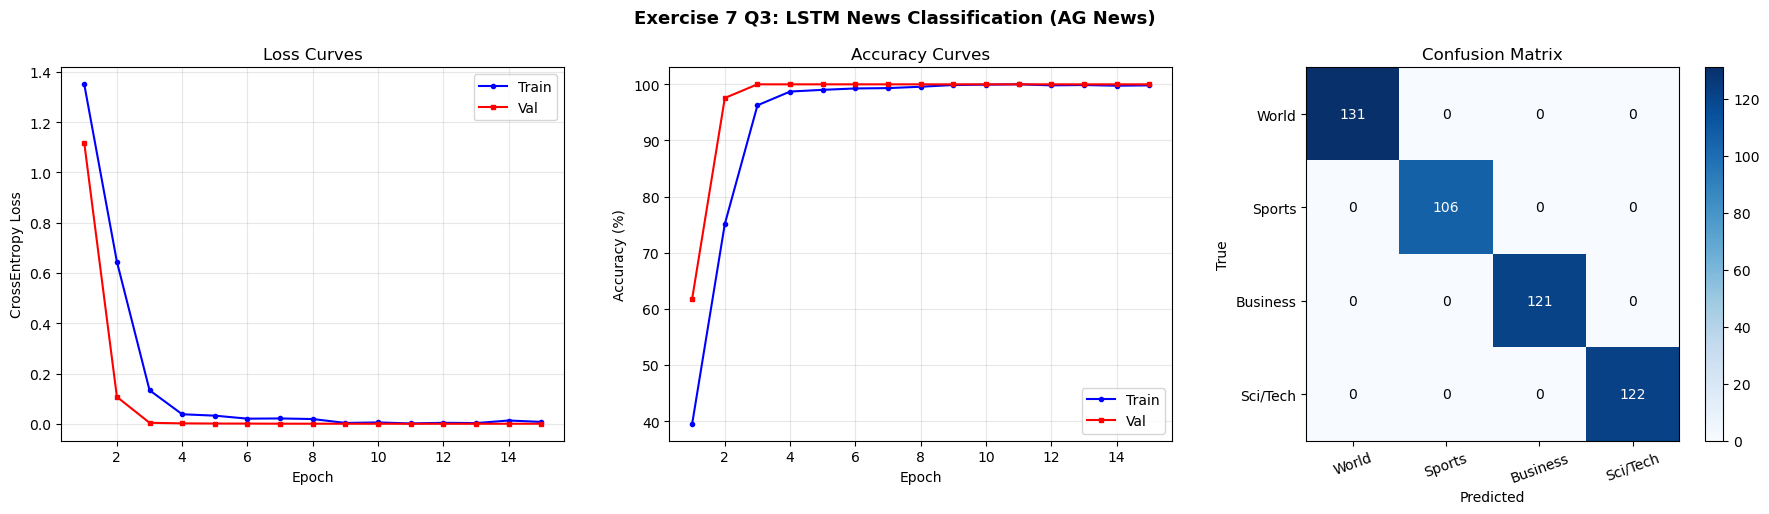

[INFO] Saved: ex7_q3_lstm_news.png
[DONE] Exercise 7 Q3 complete.


In [4]:
"""
=============================================================================
Exercise 7 — Question 3: News Classification with LSTM (PyTorch)
Dataset: AG News corpus (4 categories)  |  CPU-compatible
=============================================================================

THEORY:
-------
LSTM (Long Short-Term Memory) adds three gates to the vanilla RNN to solve
the vanishing gradient problem:

  Forget gate:  f_t = σ(W_f·[h_{t-1}, x_t] + b_f)
                "How much of the cell state should we forget?"
  
  Input gate:   i_t = σ(W_i·[h_{t-1}, x_t] + b_i)
  Candidate:   C̃_t = tanh(W_C·[h_{t-1}, x_t] + b_C)
                "What new information should we add?"
  
  Cell update:  C_t = f_t ⊙ C_{t-1} + i_t ⊙ C̃_t
                "Update cell state: forget old + add new"
  
  Output gate:  o_t = σ(W_o·[h_{t-1}, x_t] + b_o)
  Hidden state: h_t = o_t ⊙ tanh(C_t)
                "What do we output?"

Key insight: C_t flows through additive connections (not multiplicative),
so gradients can propagate without exponential decay → long-term memory.

Text Classification Pipeline:
  Raw text → Tokenize → Numericalize → Pad sequences → Embed → LSTM → FC
  
Embedding Layer:
  Maps integer token index → dense vector of size embed_dim.
  We use random initialization (can be replaced with GloVe/Word2Vec).
  The embedding is learned jointly with the classification task.

We use gradient clipping during training (torch.nn.utils.clip_grad_norm_).
=============================================================================
"""

import re
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torch.nn.utils.rnn import pad_sequence

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix)
import seaborn as sns

# Reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
DEVICE = torch.device("cpu")
print(f"[INFO] Using device: {DEVICE}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Load AG News (or generate synthetic data)
# ─────────────────────────────────────────────────────────────────────────────

def load_agnews_or_synthetic():
    """
    Tries to load AG News via torchtext. Falls back to synthetic data.
    
    AG News: 120,000 news articles, 4 categories:
      0 = World    1 = Sports    2 = Business    3 = Sci/Tech
    
    Synthetic fallback: keyword-based sentences simulating each category.
    This ensures the code runs even without internet access.
    """
    try:
        from torchtext.datasets import AG_NEWS
        from torchtext.data.utils import get_tokenizer
        tokenizer = get_tokenizer("basic_english")

        print("[INFO] Loading AG News dataset...")
        train_iter, test_iter = AG_NEWS(split=('train', 'test'))
        train_data = [(label - 1, tokenizer(text)) for label, text in train_iter]
        test_data  = [(label - 1, tokenizer(text)) for label, text in test_iter]

        # Subsample for CPU speed
        random.shuffle(train_data); random.shuffle(test_data)
        train_data = train_data[:8000]
        test_data  = test_data[:2000]
        class_names = ["World", "Sports", "Business", "Sci/Tech"]
        print(f"[INFO] Loaded AG News: {len(train_data)} train, {len(test_data)} test")
        return train_data, test_data, class_names

    except Exception as e:
        print(f"[WARN] Could not load AG News ({e}). Using synthetic data.")

    # ── Synthetic fallback ──
    templates = {
        0: ["world summit leaders meet today", "global conflict in region escalates",
            "united nations assembly votes on resolution", "international diplomacy efforts continue",
            "foreign minister announces policy change", "bilateral talks between nations resume"],
        1: ["team wins championship in final game", "athlete breaks world record today",
            "football league announces new season schedule", "olympic gold medal ceremony held",
            "basketball playoffs begin with surprise result", "tennis star wins grand slam title"],
        2: ["stock market reaches all time high today", "company reports quarterly earnings results",
            "federal reserve adjusts interest rate policy", "startup raises series funding round",
            "merger acquisition deal announced today", "inflation rate affects consumer prices"],
        3: ["artificial intelligence research breakthrough announced", "new smartphone model released",
            "scientists discover new exoplanet system", "machine learning algorithm improves accuracy",
            "quantum computing milestone achieved today", "cybersecurity researchers find vulnerability"]
    }

    def tokenize(text):
        return re.findall(r'\b\w+\b', text.lower())

    data = []
    for cls, texts in templates.items():
        for _ in range(600):
            base = random.choice(texts)
            # Add random words to simulate longer sentences
            words = base.split() + random.choices(
                ["the", "a", "new", "major", "key", "top", "said", "year", "data",
                 "report", "analysis", "study", "review", "update", "change"], k=10)
            random.shuffle(words)
            sentence = " ".join(words[:20])
            data.append((cls, tokenize(sentence)))

    random.shuffle(data)
    split = int(0.8 * len(data))
    class_names = ["World", "Sports", "Business", "Sci/Tech"]
    print(f"[INFO] Synthetic: {split} train, {len(data)-split} test")
    return data[:split], data[split:], class_names


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Vocabulary + Numericalization
# ─────────────────────────────────────────────────────────────────────────────

class Vocabulary:
    """
    Maps tokens (strings) to integer indices.
    
    Special tokens:
    - <PAD> (index 0): used to pad shorter sequences to equal length
    - <UNK> (index 1): replaces unknown words not in vocabulary
    
    We only keep words that appear >= min_freq times to avoid noise
    from very rare words.
    """
    PAD_IDX = 0
    UNK_IDX = 1

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word = {0: "<PAD>", 1: "<UNK>"}

    def build(self, token_lists):
        counter = Counter(tok for tokens in token_lists for tok in tokens)
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        print(f"[INFO] Vocabulary size: {len(self.word2idx)}")

    def encode(self, tokens, max_len=100):
        """Converts token list to integer indices, truncated/padded to max_len."""
        indices = [self.word2idx.get(t, self.UNK_IDX) for t in tokens[:max_len]]
        return indices

    def __len__(self):
        return len(self.word2idx)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: PyTorch Dataset
# ─────────────────────────────────────────────────────────────────────────────

class NewsDataset(Dataset):
    """
    Converts (label, tokens) pairs to (tensor_of_indices, label) pairs.
    Handles variable-length sequences via padding in collate_fn.
    """
    def __init__(self, data, vocab, max_len=100):
        self.data = data
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label, tokens = self.data[idx]
        indices = self.vocab.encode(tokens, self.max_len)
        return torch.tensor(indices, dtype=torch.long), label


def collate_fn(batch):
    """
    Pads sequences in a batch to the same length.
    
    PyTorch requires all samples in a batch to have the same size.
    We pad shorter sequences with PAD_IDX (0) so they match the longest.
    
    batch_first=True → output shape: (batch_size, max_seq_len)
    """
    sequences, labels = zip(*batch)
    sequences_padded = pad_sequence(sequences, batch_first=True,
                                    padding_value=Vocabulary.PAD_IDX)
    return sequences_padded, torch.tensor(labels, dtype=torch.long)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: LSTM Model
# ─────────────────────────────────────────────────────────────────────────────

class LSTMClassifier(nn.Module):
    """
    LSTM-based text classification model.
    
    Architecture:
    Input indices → Embedding → LSTM → Dropout → Linear
    
    Embedding layer:
      - vocab_size × embed_dim matrix (learnable)
      - padding_idx=0: ensures PAD vectors remain zero (no gradient)
    
    LSTM layer:
      - hidden_size=128: size of hidden state vector
      - num_layers=2: stacked LSTM (2 layers deep)
      - batch_first=True: input is (batch, seq, features)
      - bidirectional=True: processes sequence forward AND backward
        → doubles effective hidden size (128 × 2 = 256)
    
    Why bidirectional?
      For classification, the entire sequence is available, so looking
      at context from both directions improves understanding.
    
    We take output[:, -1, :] — final hidden state (summary of all words).
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_size=128,
                 num_layers=2, num_classes=4, dropout=0.4):
        super(LSTMClassifier, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=Vocabulary.PAD_IDX  # PAD vectors don't contribute to gradient
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,  # inter-layer dropout
            bidirectional=True   # processes text both ways
        )

        self.dropout = nn.Dropout(dropout)

        # bidirectional doubles output size: hidden_size × 2
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.dropout(self.embedding(x))  # → (batch, seq_len, embed_dim)

        # lstm_out: (batch, seq_len, hidden*2)
        # (h_n, c_n): final hidden & cell states
        lstm_out, (h_n, c_n) = self.lstm(emb)

        # Take LAST timestep output (summary of the full sequence)
        # lstm_out[:, -1, :] → (batch, hidden*2)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        logits = self.fc(out)  # → (batch, num_classes)
        return logits


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Training Loop
# ─────────────────────────────────────────────────────────────────────────────

def train_lstm(model, train_loader, val_loader, epochs=15, lr=1e-3, clip_norm=1.0):
    """
    Training with gradient clipping.
    
    Gradient clipping (clip_grad_norm_):
    - Clips the global gradient norm to max 1.0.
    - Prevents exploding gradients, stabilizes training.
    - More important for RNNs/LSTMs than for CNNs.
    
    Loss: CrossEntropyLoss = log-softmax + negative log-likelihood
    Optimizer: Adam — adaptive per-parameter learning rates.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    model.to(DEVICE)

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(seqs)
            loss = criterion(logits, labels)
            loss.backward()

            # Gradient clipping — IMPORTANT for LSTMs
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)

            optimizer.step()
            train_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

        # ── Validate ──
        model.eval()
        val_loss, vcorrect, vtotal = 0.0, 0, 0
        with torch.no_grad():
            for seqs, labels in val_loader:
                seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)
                logits = model(seqs)
                loss = criterion(logits, labels)
                val_loss += loss.item() * labels.size(0)
                vcorrect += (logits.argmax(1) == labels).sum().item()
                vtotal += labels.size(0)

        tl = train_loss/total; ta = correct/total*100
        vl = val_loss/vtotal;  va = vcorrect/vtotal*100
        scheduler.step(vl)

        history["train_loss"].append(tl); history["val_loss"].append(vl)
        history["train_acc"].append(ta);  history["val_acc"].append(va)
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {tl:.4f} Acc: {ta:.1f}% | "
              f"Val Loss: {vl:.4f} Acc: {va:.1f}%")

    return history


# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: Evaluation
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_full(model, test_loader, class_names):
    """
    Full evaluation on test set:
    - Collects all predictions and true labels
    - Computes precision/recall/F1 (macro: unweighted average across classes)
    - Plots confusion matrix
    
    Confusion Matrix:
    - Rows: true class, Columns: predicted class
    - Diagonal = correct predictions
    - Off-diagonal = misclassifications (tells you WHICH classes are confused)
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs = seqs.to(DEVICE)
            logits = model(seqs)
            preds = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    cm   = confusion_matrix(all_labels, all_preds)

    print("\n========== Test Set Evaluation ==========")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Precision : {prec:.2f}% (macro)")
    print(f"  Recall    : {rec:.2f}% (macro)")
    print(f"  F1-Score  : {f1:.2f}% (macro)")
    print("==========================================\n")

    return all_preds, all_labels, cm, {"acc": acc, "prec": prec, "rec": rec, "f1": f1}


# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: Plotting
# ─────────────────────────────────────────────────────────────────────────────

def plot_all(history, cm, class_names, epochs):
    ep = range(1, epochs + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Exercise 7 Q3: LSTM News Classification (AG News)",
                 fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(ep, history["train_loss"], 'b-o', label="Train", markersize=3)
    axes[0].plot(ep, history["val_loss"],   'r-s', label="Val", markersize=3)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("CrossEntropy Loss")
    axes[0].set_title("Loss Curves"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(ep, history["train_acc"], 'b-o', label="Train", markersize=3)
    axes[1].plot(ep, history["val_acc"],   'r-s', label="Val", markersize=3)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Accuracy Curves"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Confusion Matrix
    im = axes[2].imshow(cm, cmap="Blues")
    axes[2].set_xticks(range(len(class_names))); axes[2].set_xticklabels(class_names, rotation=20)
    axes[2].set_yticks(range(len(class_names))); axes[2].set_yticklabels(class_names)
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
    axes[2].set_title("Confusion Matrix")
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            axes[2].text(j, i, str(cm[i, j]), ha='center', va='center',
                         color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=10)
    plt.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.savefig("ex7_q3_lstm_news.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("[INFO] Saved: ex7_q3_lstm_news.png")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("  Exercise 7, Q3: LSTM News Classification")
    print("=" * 60)

    EPOCHS = 15; BATCH = 64; MAX_LEN = 100; EMBED_DIM = 128
    NUM_CLASSES = 4

    # Load data
    train_data, test_data, class_names = load_agnews_or_synthetic()

    # Build vocabulary
    vocab = Vocabulary(min_freq=2)
    vocab.build([tokens for _, tokens in train_data])

    # Datasets + Splits
    train_ds = NewsDataset(train_data, vocab, MAX_LEN)
    test_ds  = NewsDataset(test_data,  vocab, MAX_LEN)

    # Split train into train/val
    n_val = int(0.15 * len(train_ds))
    n_train = len(train_ds) - n_val
    train_sub, val_sub = random_split(train_ds, [n_train, n_val])

    train_loader = DataLoader(train_sub, batch_size=BATCH, shuffle=True, collate_fn=collate_fn)
    val_loader   = DataLoader(val_sub,   batch_size=BATCH, collate_fn=collate_fn)
    test_loader  = DataLoader(test_ds,   batch_size=BATCH, collate_fn=collate_fn)

    print(f"[INFO] Train: {n_train} | Val: {n_val} | Test: {len(test_ds)}")

    # Build model
    model = LSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_size=128,
        num_layers=2,
        num_classes=NUM_CLASSES,
        dropout=0.4
    )
    total_params = sum(p.numel() for p in model.parameters())
    print(f"[INFO] Model parameters: {total_params:,}")
    print(model)

    # Train
    history = train_lstm(model, train_loader, val_loader,
                         epochs=EPOCHS, lr=1e-3, clip_norm=1.0)

    # Evaluate
    preds, labels, cm, metrics = evaluate_full(model, test_loader, class_names)

    # Plot
    plot_all(history, cm, class_names, EPOCHS)

    print("[DONE] Exercise 7 Q3 complete.")
